# Degrading

In this notebook we will:
- apply degradation (and preprocessing) and save all images from the data/raw directory into data/degraded directory

In [4]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import cv2

src_path = os.path.abspath(os.path.join("..", "src"))
if src_path not in sys.path:
    sys.path.insert(0, src_path)
from degradation import apply_degradation_and_preprocess, apply_degradation
from preprocess import preprocess_image_array

In [2]:
# read in image metadata df
parent_dir = Path.cwd().parent
df = pd.read_csv(parent_dir / "data/image_metadata.csv")
df.head()

,disease,label,patient_id,image_num,filename,path
0,CNV,1,3453634,13,CNV-3453634-13.jpeg,/home/lance/Projects/SML/COMP90051_A2/data/raw...
1,CNV,1,7513011,89,CNV-7513011-89.jpeg,/home/lance/Projects/SML/COMP90051_A2/data/raw...
2,DME,2,5313093,77,DME-5313093-77.jpeg,/home/lance/Projects/SML/COMP90051_A2/data/raw...
3,CNV,1,9374492,279,CNV-9374492-279.jpeg,/home/lance/Projects/SML/COMP90051_A2/data/raw...
4,NORMAL,0,5768195,14,NORMAL-5768195-14.jpeg,/home/lance/Projects/SML/COMP90051_A2/data/raw...


In [3]:
# degraded path
degraded_dir = parent_dir / "data" / "degraded"
degraded_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
for index, row in df.iterrows():
    img = apply_degradation_and_preprocess(row["path"], corruption_type=None, severity=None, size=224)
    cv2.imwrite(degraded_dir / row["filename"], img.astype(np.uint8))

# Examples of how this degradation applies to the first image of the data at severity = 2

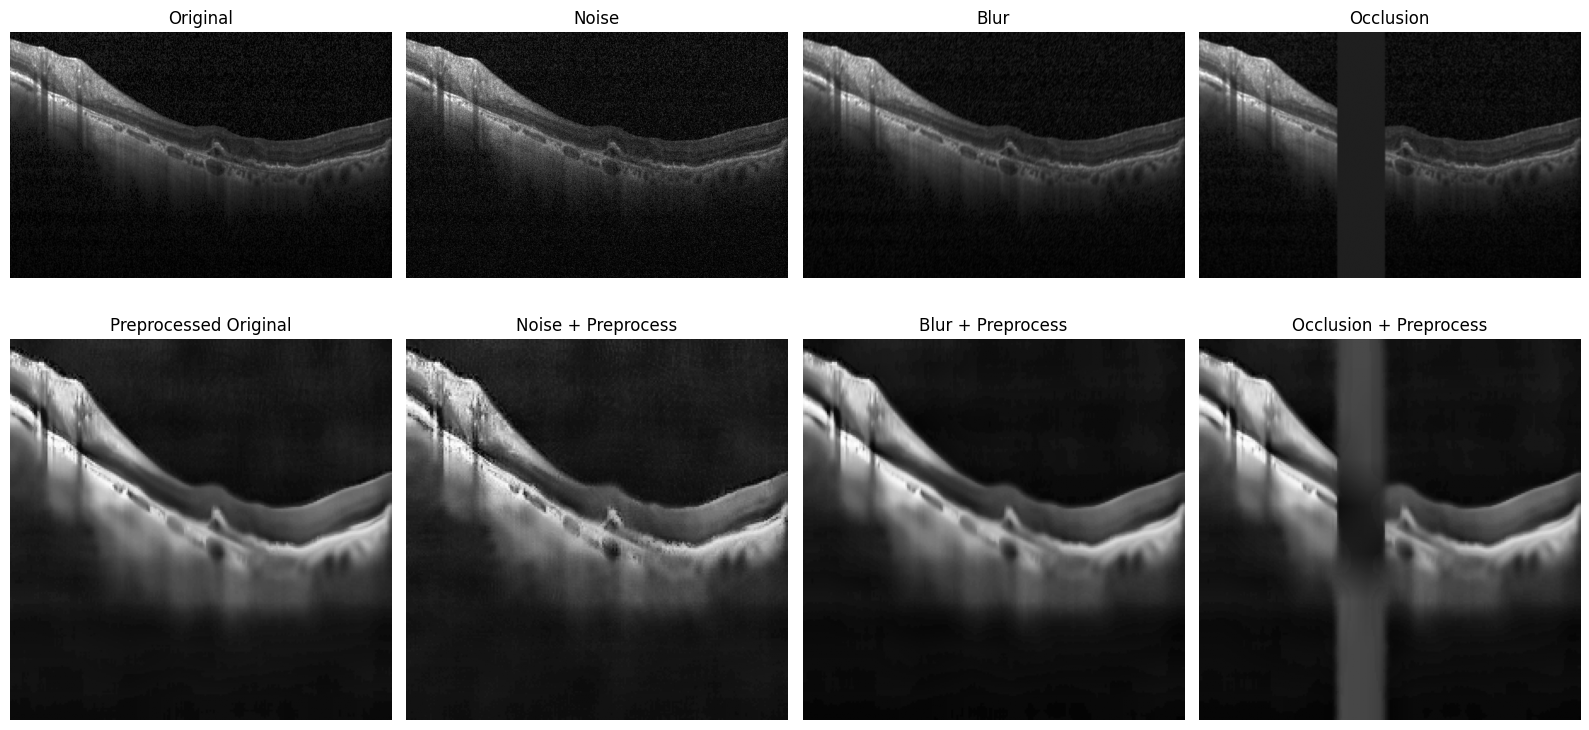

In [ ]:
import matplotlib.pyplot as plt

# get first image from dataframe
row = df.iloc[0]

# original image
original = cv2.imread(row["path"], cv2.IMREAD_GRAYSCALE)

# apply each corruption at severity 2
noise_img = apply_degradation(original, corruption_type="noise", severity=2)

blur_img = apply_degradation(original, corruption_type="blur", severity=2)

occlusion_img = apply_degradation(original, corruption_type="occlusion", severity=2)


noise_processed = preprocess_image_array(noise_img, 224)
blur_processed = preprocess_image_array(blur_img, 224)
occlusion_processed = preprocess_image_array(occlusion_img, 224)


fig, axes = plt.subplots(2, 4, figsize=(16, 8))

axes[0, 0].imshow(original, cmap="gray")
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

axes[0, 1].imshow(noise_img, cmap="gray")
axes[0, 1].set_title("Noise")
axes[0, 1].axis("off")

axes[0, 2].imshow(blur_img, cmap="gray")
axes[0, 2].set_title("Blur")
axes[0, 2].axis("off")

axes[0, 3].imshow(occlusion_img, cmap="gray")
axes[0, 3].set_title("Occlusion")
axes[0, 3].axis("off")

axes[1, 0].imshow(preprocess_image_array(original, 224), cmap="gray")
axes[1, 0].set_title("Preprocessed Original")
axes[1, 0].axis("off")

axes[1, 1].imshow(noise_processed, cmap="gray")
axes[1, 1].set_title("Noise + Preprocess")
axes[1, 1].axis("off")

axes[1, 2].imshow(blur_processed, cmap="gray")
axes[1, 2].set_title("Blur + Preprocess")
axes[1, 2].axis("off")

axes[1, 3].imshow(occlusion_processed, cmap="gray")
axes[1, 3].set_title("Occlusion + Preprocess")
axes[1, 3].axis("off")

plt.tight_layout()
plt.show()